# Day 54 — Apply & Lambda: Custom Logic on Every Row
**Month 3 | Week 5 | `.apply()` · `.map()` · Lambda · Row-wise Functions**

---

> **Real-world framing:**
>
> A client hands you a dataset and says:
> *"Tag each order as 'High Value', 'Mid Value', or 'Low Value' based on revenue.
> Then flag any order where the unit price is above the category average.
> And reformat the order IDs to match our internal system."*
>
> None of these can be done with a single built-in Pandas method.
> They need **custom logic** — your own rules, applied to every row or cell.
> That's exactly what `.apply()` and lambda functions are for.
>
> Apply is what separates analysts who can only use pre-built functions
> from analysts who can implement *any* business rule the client invents.

---

**Skills used today:** Pandas basics (Day 33–35), GroupBy (Day 39),
Feature Engineering (Day 45/49), Window Functions (Day 53)
**New today:** `lambda` functions · `Series.apply()` · `DataFrame.apply()` (row-wise) ·
`Series.map()` · `pd.cut()` vs apply for binning · performance awareness

**Total: 80 pts + 10★ bonus**

---


---
## 📦 Section 1 — Raw Data (Read Only — Never Modify)

Same ShopEase dataset (200 records, seed=7). Run once. Work on copies only.

In [59]:
# ── RAW DATA — DO NOT MODIFY BELOW THIS CELL ──────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

rng = np.random.default_rng(seed=7)

n = 200
regions    = ['North', 'South', 'East', 'West']
categories = ['Electronics', 'Clothing', 'Home', 'Sports', 'Books']
segments   = ['Regular', 'Premium', 'VIP']
statuses   = ['Delivered', 'Returned', 'Pending']

raw = pd.DataFrame({
    'order_id'    : [f'ORD{1000+i}' for i in range(n)],
    'order_date'  : pd.date_range('2024-01-01', periods=n, freq='2D'),
    'region'      : rng.choice(regions,    n, p=[0.30, 0.25, 0.25, 0.20]),
    'category'    : rng.choice(categories, n, p=[0.30, 0.25, 0.20, 0.15, 0.10]),
    'product'     : [f'P{rng.integers(100,150):03d}' for _ in range(n)],
    'units'       : rng.integers(1, 20, n),
    'unit_price'  : rng.uniform(50, 500, n).round(2),
    'discount_pct': rng.choice([0, 5, 10, 15, 20], n, p=[0.4,0.2,0.2,0.1,0.1]),
    'segment'     : rng.choice(segments,   n, p=[0.50, 0.30, 0.20]),
    'status'      : rng.choice(statuses,   n, p=[0.70, 0.21, 0.09]),
})
raw['revenue'] = (raw['units'] * raw['unit_price'] *
                  (1 - raw['discount_pct']/100)).round(2)
raw['month']   = raw['order_date'].dt.to_period('M')
raw['quarter'] = raw['order_date'].dt.to_period('Q')

df = raw.copy()
print(f"Dataset: {df.shape}")
print(df[['order_id','region','category','units','unit_price','revenue','segment']].head(5))
# ── END RAW DATA ──────────────────────────────────────────────────────────


Dataset: (200, 13)
  order_id region     category  units  unit_price  revenue  segment
0  ORD1000   East       Sports     19      433.17  6584.18      VIP
1  ORD1001   West         Home      8      389.99  3119.92      VIP
2  ORD1002   East         Home      6      201.51  1027.70  Premium
3  ORD1003  North  Electronics     16       84.87  1290.02  Premium
4  ORD1004  South         Home      9      109.50   886.95  Regular


---
## 📖 Section 2 — Concept Notes

---

### What Is `.apply()`?

`.apply()` runs a function — built-in or custom — on every element of a Series,
or on every row/column of a DataFrame. It's the bridge between Pandas and arbitrary Python logic.

```
Series.apply(func)         → one output per row
DataFrame.apply(func, axis=0)   → one output per column (default)
DataFrame.apply(func, axis=1)   → one output per row ← most common use
```

---

### 1. Lambda Functions

A **lambda** is an anonymous single-expression function. Identical to a `def` but written inline.

```python
# Regular function
def square(x):
    return x ** 2

# Lambda equivalent
square = lambda x: x ** 2

# Most common pattern — used directly inside apply()
df['rev_squared'] = df['revenue'].apply(lambda x: x ** 2)
```

**Rule:** If your logic fits in one expression → lambda. If it needs if/else chains or >1 line → write a named function and pass it to apply().

---

### 2. Series.apply() — Column-wise custom logic

```python
# Tag each order by revenue tier
def revenue_tier(rev):
    if rev >= 5000:
        return 'High'
    elif rev >= 2000:
        return 'Mid'
    else:
        return 'Low'

df['tier'] = df['revenue'].apply(revenue_tier)

# Lambda version (one-liner with nested ternary)
df['tier'] = df['revenue'].apply(
    lambda x: 'High' if x >= 5000 else ('Mid' if x >= 2000 else 'Low')
)
```

---

### 3. DataFrame.apply(axis=1) — Row-wise logic using multiple columns

This is the most powerful pattern — your function sees the **entire row** as a Series.

```python
# Gross profit uses both unit_price AND units AND discount_pct — needs the full row
def gross_profit(row):
    gross = row['units'] * row['unit_price']           # before discount
    net   = gross * (1 - row['discount_pct'] / 100)   # after discount
    return round(gross - net, 2)                       # discount amount lost

df['discount_amount'] = df.apply(gross_profit, axis=1)

# Lambda equivalent (row is passed as a named variable)
df['discount_amount'] = df.apply(
    lambda row: round(row['units'] * row['unit_price'] * row['discount_pct'] / 100, 2),
    axis=1
)
```

---

### 4. Series.map() — Lookup / recode from a dictionary

`.map()` is the fastest way to recode a column using a fixed mapping.
Use it instead of apply() when you have a known dictionary of replacements.

```python
tier_label = {'Regular': 'Standard', 'Premium': 'Priority', 'VIP': 'Elite'}
df['segment_label'] = df['segment'].map(tier_label)

# map() also accepts a function — but apply() is preferred for functions
# map() with a dict is significantly faster than apply() with if/else
```

---

### 5. When NOT to use apply()

Apply runs Python code row-by-row — it's **slow** on large datasets.
Prefer vectorized operations whenever possible:

| Task | ❌ apply (slow) | ✅ vectorized (fast) |
|------|----------------|----------------------|
| Add 10 to revenue | `df['revenue'].apply(lambda x: x+10)` | `df['revenue'] + 10` |
| Multiply two columns | `df.apply(lambda r: r['units']*r['price'], axis=1)` | `df['units'] * df['price']` |
| String upper | `df['col'].apply(lambda x: x.upper())` | `df['col'].str.upper()` |
| Custom business rule | No alternative | **Use apply()** |

**Apply is justified when:** the logic can't be expressed as a vectorized operation — custom tiers, multi-condition flags, string reformatting with business rules, multi-column lookups.

---

### Common Mistakes & Fixes

| Mistake | Fix |
|---------|-----|
| `apply(func())` — calling the function instead of passing it | `apply(func)` — no parentheses |
| Forgetting `axis=1` for row-wise | `df.apply(func, axis=1)` |
| Using apply for simple math | Use vectorized `+`, `*`, etc. — 10–100× faster |
| Lambda with multiple statements | Write a named `def` instead |
| Mutating `row` inside apply | Return a value; don't modify the row in-place |

---

### Interview One-liner
> "`.apply()` lets me implement any business rule that can't be expressed as a vectorized
> Pandas operation — custom revenue tiers, multi-column flags, string reformatting.
> For simple arithmetic I always use vectorized operations instead because apply()
> loops in Python and is 10–100× slower on large DataFrames."

---


---
## ✏️ Section 3 — Practice Tasks

Work only in this section. Never modify raw data.
Total = **80 pts + 10★ bonus**.

---

### Task A — Series.apply() with Named Functions (20 pts)

**Business question:** The client's CRM tags orders into three tiers for follow-up prioritisation.
Your job is to apply those exact tier rules to every order.

#### A1 — Revenue Tier Function (8 pts)
Write a named function `revenue_tier(rev)` with these rules:
- `>= 5000` → `'High Value'`
- `>= 2000` → `'Mid Value'`
- else → `'Low Value'`

Apply it to `df['revenue']`. Store as `df['rev_tier']`.  
Print the value counts of `rev_tier` and the first 8 rows showing `order_id`, `revenue`, `rev_tier`.


In [60]:
# A1 — Revenue Tier Named Function (8 pts)
# Step 1: Define revenue_tier(rev) function with the 3 tiers
# Step 2: Apply to df['revenue'] → df['rev_tier']
# Step 3: Print value_counts() of rev_tier
# Step 4: Print first 8 rows: order_id, revenue, rev_tier
ak = df.copy()

def revenue_tier(rev):
    if rev >=5000:   return 'High Value'
    elif rev >=2000: return 'Mid Value'
    else:            return 'Low Value'

ak['rev_tier'] = ak['revenue'].apply(revenue_tier)
print("=== A1 value counts ===")
print(ak['rev_tier'].value_counts())
print()
print(ak[['order_id', 'revenue', 'rev_tier']].head(8).to_string(index = False))

=== A1 value counts ===
rev_tier
Low Value     112
Mid Value      64
High Value     24
Name: count, dtype: int64

order_id  revenue   rev_tier
 ORD1000  6584.18 High Value
 ORD1001  3119.92  Mid Value
 ORD1002  1027.70  Low Value
 ORD1003  1290.02  Low Value
 ORD1004   886.95  Low Value
 ORD1005  1807.71  Low Value
 ORD1006   597.63  Low Value
 ORD1007  2262.42  Mid Value


#### A2 — Discount Severity (7 pts)
Write a named function `discount_label(pct)`:
- `0` → `'No Discount'`
- `5` or `10` → `'Moderate'`
- `15` or `20` → `'Heavy'`

Apply to `df['discount_pct']` → `df['discount_label']`.  
Print value counts and 5 rows showing `order_id`, `discount_pct`, `discount_label`.


In [61]:
# A2 — Discount Severity Label (7 pts)
# Step 1: Define discount_label(pct) with 3 categories
# Step 2: Apply → df['discount_label']
# Step 3: Print value_counts()
# Step 4: Print 5 rows: order_id, discount_pct, discount_label
def discount_label(pct):
    if pct ==0:            return 'No Discount'
    elif pct in [5, 10]:   return 'Moderate'
    else:                  return 'Heavy'

ak['discount_label'] = ak['discount_pct'].apply(discount_label)
print("=== A2 value_counts ===")
print(ak['discount_label'].value_counts())
print()
print(ak[['order_id', 'discount_pct', 'discount_label']].head(5).to_string(index = False))

=== A2 value_counts ===
discount_label
No Discount    88
Moderate       69
Heavy          43
Name: count, dtype: int64

order_id  discount_pct discount_label
 ORD1000            20          Heavy
 ORD1001             0    No Discount
 ORD1002            15          Heavy
 ORD1003             5       Moderate
 ORD1004            10       Moderate


#### A3 — Insight (5 pts)
Write one NRA markdown insight:  
**N** — What % of orders are 'High Value'? (cite exact number from your output)  
**R** — What does this distribution imply about the typical order profile?  
**A** — What one action should the client take to grow the High Value segment?


<!-- A3 — WRITE YOUR NRA INSIGHT HERE -->

**N: From your output, 12% of orders are High Value (24 out of 200).**

**R: A heavy concentration in Low Value orders (56%) implies the customer base is dominated by small transactions; high-value transactions are rare, which may skew marketing ROI.**

**A: The client should create a targeted up‑sell campaign for Mid Value customers (e.g., threshold‑based discounts to push them into ≥₹5000) to grow the High Value segment.**


---

### Task B — Lambda Functions (20 pts)

**Business question:** The client wants several quick derived columns for their reporting dashboard.
All rules are simple enough for one-liners — use lambda for all of B.

#### B1 — Revenue Per Unit (5 pts)
Using a **lambda**, create `df['rev_per_unit']` = `revenue / units`, rounded to 2 decimal places.  
Print 5 rows: `order_id`, `revenue`, `units`, `rev_per_unit`.


In [62]:
# B1 — Revenue Per Unit via Lambda (5 pts)
# Use df['revenue'].apply(lambda x: ...) — but you need both revenue AND units
# Hint: you need axis=1 or a different approach since you need two columns
# Add rev_per_unit = revenue / units, rounded to 2dp
# Print 5 rows: order_id, revenue, units, rev_per_unit
ak['rev_per_unit'] = ak.apply(lambda row: round(row['revenue'] / row['units'], 2), axis = 1)
print("=== B1 (first 5) ===")
print(ak[['order_id', 'revenue', 'units', 'rev_per_unit']].head(5).to_string(index = False))


=== B1 (first 5) ===
order_id  revenue  units  rev_per_unit
 ORD1000  6584.18     19        346.54
 ORD1001  3119.92      8        389.99
 ORD1002  1027.70      6        171.28
 ORD1003  1290.02     16         80.63
 ORD1004   886.95      9         98.55


#### B2 — Order ID Reformatter (8 pts)
The client's internal system expects order IDs in the format `SHOPEASE-####`
(e.g., `ORD1000` → `SHOPEASE-1000`).

Using a **lambda**, create `df['order_id_new']` with the reformatted IDs.  
Print 6 rows: `order_id`, `order_id_new`.

**Hint:** You need to strip `'ORD'` and prepend `'SHOPEASE-'`.


In [63]:
# B2 — Order ID Reformatter via Lambda (8 pts)
# Lambda: take order_id string, strip 'ORD', prepend 'SHOPEASE-'
# Store as df['order_id_new']
# Print 6 rows: order_id, order_id_new
ak['order_id_new'] = ak['order_id'].apply(lambda x: 'SHOPEASE-' + x.replace('ORD', ''))
print("=== B2 (first 6)=== ")
print(ak[['order_id', 'order_id_new']].head(6).to_string(index = False))


=== B2 (first 6)=== 
order_id  order_id_new
 ORD1000 SHOPEASE-1000
 ORD1001 SHOPEASE-1001
 ORD1002 SHOPEASE-1002
 ORD1003 SHOPEASE-1003
 ORD1004 SHOPEASE-1004
 ORD1005 SHOPEASE-1005


#### B3 — Priority Flag (7 pts)
Create `df['priority']` using a **lambda**:
- `'VIP'` segment AND `'Delivered'` status → `'URGENT'`
- `'VIP'` segment OR revenue >= 5000 → `'HIGH'`
- Everything else → `'STANDARD'`

This requires checking multiple columns — use `axis=1`.  
Print value counts of `priority` and 5 rows showing `order_id`, `segment`, `status`, `revenue`, `priority`.


In [83]:
# B3 — Priority Flag via Lambda with axis=1 (7 pts)
# Lambda must access row['segment'], row['status'], row['revenue']
# Three tiers: URGENT > HIGH > STANDARD
# Use df.apply(lambda row: ..., axis=1)
# Print value_counts() and 5 rows with 5 columns
ak['priority'] = ak.apply(
    lambda row: 'URGENT' if (row['segment'] == 'VIP' and row['status'] == 'Delivered')
                else 'HIGH' if (row['segment'] == 'VIP' or row['revenue'] >= 5000)
                else 'STANDARD',
    axis=1
)
print("=== B3 value_counts ===")
print(ak['priority'].value_counts())
print()
print(ak[['order_id','segment','status','revenue','priority']].head(5).to_string(index=False))

=== B3 value_counts ===
priority
STANDARD    134
HIGH         36
URGENT       30
Name: count, dtype: int64

order_id segment    status  revenue priority
 ORD1000     VIP Delivered  6584.18   URGENT
 ORD1001     VIP  Returned  3119.92     HIGH
 ORD1002 Premium Delivered  1027.70 STANDARD
 ORD1003 Premium  Returned  1290.02 STANDARD
 ORD1004 Regular  Returned   886.95 STANDARD


---

### Task C — DataFrame.apply(axis=1) with Named Functions (20 pts)

**Business question:** The client's finance team needs two derived columns that require
reading multiple raw fields simultaneously — exactly what row-wise apply is built for.

#### C1 — Effective Revenue Score (10 pts)
Write a named function `revenue_score(row)` that returns:

```
score = (revenue / unit_price) * (1 + units / 10) * (1 - discount_pct / 100)
```

Round to 4 decimal places.  
Apply with `axis=1` → `df['rev_score']`.  
Print descriptive stats (`.describe()`) of `rev_score` and first 6 rows:
`order_id`, `revenue`, `units`, `discount_pct`, `rev_score`.


In [65]:
# C1 — Revenue Score Row-wise Function (10 pts)
# Step 1: Define revenue_score(row) using the formula above
# Step 2: df.apply(revenue_score, axis=1) → df['rev_score']
# Step 3: Print df['rev_score'].describe()
# Step 4: Print first 6 rows: order_id, revenue, units, discount_pct, rev_scor
def revenue_score(row):
    score = (row['revenue'] / row['unit_price']) * (1 + row['units']/10) * (1 - row['discount_pct']/100)
    return round(score, 4)

ak['rev_score'] = ak.apply(revenue_score, axis = 1)
print("=== C1 describe ===")
print(ak['rev_score'].describe().round(4))
print()
print(ak[['order_id', 'revenue', 'units', 'discount_pct', 'rev_score']].head(6).to_string(index = False))


=== C1 describe ===
count    200.0000
mean      19.4261
std       14.6603
min        0.7040
25%        6.7687
50%       15.8164
75%       29.9000
max       55.1000
Name: rev_score, dtype: float64

order_id  revenue  units  discount_pct  rev_score
 ORD1000  6584.18     19            20    35.2640
 ORD1001  3119.92      8             0    14.4000
 ORD1002  1027.70      6            15     6.9360
 ORD1003  1290.02     16             5    37.5439
 ORD1004   886.95      9            10    13.8510
 ORD1005  1807.71     16            15    30.0560


#### C2 — Above-Category-Average Price Flag (10 pts)
For each order, flag whether its `unit_price` is **above** the average `unit_price`
for its `category`.

Steps:
1. Compute category average unit price using `groupby().transform('mean')`
2. Write a named function `price_flag(row)` that returns `'Above Avg'` if `unit_price > cat_avg_price`, else `'Below Avg'`
3. Apply with `axis=1` → `df['price_flag']`
4. Print crosstab of `category` vs `price_flag` (counts)
5. Print 5 rows: `order_id`, `category`, `unit_price`, `price_flag`


In [66]:
# C2 — Above-Category-Average Price Flag (10 pts)
# Step 1: Add df['cat_avg_price'] = groupby('category')['unit_price'].transform('mean').round(2)
# Step 2: Define price_flag(row) comparing row['unit_price'] to row['cat_avg_price']
# Step 3: df.apply(price_flag, axis=1) → df['price_flag']
# Step 4: Print pd.crosstab(df['category'], df['price_flag'])
# Step 5: Print 5 rows: order_id, category, unit_price, price_flag
ak['cat_avg_price'] = ak.groupby('category')['unit_price'].transform('mean').round(2)

def price_flag(row):
    return 'Above Avg' if row['unit_price'] > row['cat_avg_price'] else 'Below Avg'

ak['price_flag'] = ak.apply(price_flag, axis = 1)
print("=== C2 crosstab ===")
print(pd.crosstab(ak['category'], ak['price_flag']))
print()
print(ak[['order_id', 'category', 'unit_price', 'price_flag']].head(5).to_string(index = False))

=== C2 crosstab ===
price_flag   Above Avg  Below Avg
category                         
Books                7         10
Clothing            21         23
Electronics         29         33
Home                17         18
Sports              21         21

order_id    category  unit_price price_flag
 ORD1000      Sports      433.17  Above Avg
 ORD1001        Home      389.99  Above Avg
 ORD1002        Home      201.51  Below Avg
 ORD1003 Electronics       84.87  Below Avg
 ORD1004        Home      109.50  Below Avg


---

### Task D — Series.map() for Recoding (10 pts)

**Business question:** The reporting dashboard uses full display labels,
not the shorthand codes in the raw data. Recode two columns using `.map()`.

#### D1 — Segment Recode (5 pts)
Using `.map()` with a dictionary, create `df['segment_display']`:
- `'Regular'` → `'Standard Customer'`
- `'Premium'` → `'Priority Customer'`
- `'VIP'` → `'Elite Customer'`

Print value counts and 4 rows: `order_id`, `segment`, `segment_display`.


In [81]:
# D1 — Segment Recode via map() (5 pts)
# Create a dictionary with 3 mappings
# df['segment_display'] = df['segment'].map(dict)
# Print value_counts() and 4 rows: order_id, segment, segment_display
seg_map = {'Regular':'Standard Customer','Premium':'Priority Customer','VIP':'Elite Customer'}
ak['segment_display'] = ak['segment'].map(seg_map)
print("=== D1 value_counts ===")
print(ak['segment_display'].value_counts())
print(ak[['order_id', 'segment', 'segment_display']].head(4).to_string(index=False))

=== D1 value_counts ===
segment_display
Standard Customer    101
Priority Customer     54
Elite Customer        45
Name: count, dtype: int64
order_id segment   segment_display
 ORD1000     VIP    Elite Customer
 ORD1001     VIP    Elite Customer
 ORD1002 Premium Priority Customer
 ORD1003 Premium Priority Customer


#### D2 — Status → Action Code (5 pts)
Using `.map()`, create `df['action_code']`:
- `'Delivered'` → `'CLOSE'`
- `'Returned'` → `'REFUND'`
- `'Pending'` → `'FOLLOW-UP'`

Print value counts and 4 rows: `order_id`, `status`, `action_code`.  

**Insight (required):** Write one NRA sentence below — what does the action code distribution
tell the client about their current workload? Cite the exact count for each code.


In [82]:
# D2 — Status Action Code via map() (5 pts)
# Create mapping dict and apply with .map()
# Print value_counts() and 4 rows: order_id, status, action_code
act_map = {'Delivered':'CLOSE','Returned':'REFUND','Pending':'FOLLOW-UP'}
ak['action_code']     = ak['status'].map(act_map)
print("=== D2 value_counts ===")
print(ak['action_code'].value_counts())
print(ak[['order_id', 'status', 'action_code']].head(4).to_string(index=False))

=== D2 value_counts ===
action_code
CLOSE        139
REFUND        41
FOLLOW-UP     20
Name: count, dtype: int64
order_id    status action_code
 ORD1000 Delivered       CLOSE
 ORD1001  Returned      REFUND
 ORD1002 Delivered       CLOSE
 ORD1003  Returned      REFUND


<!-- D2 NRA INSIGHT — WRITE HERE -->

**N: CLOSE = 139, REFUND = 41, FOLLOW-UP = 20.**

**R: The majority of orders (69.5%) are already delivered and require only closure, while returns represent 20.5% of the workload — a non‑trivial customer service burden.**

**A: The client should investigate the root cause of returns (product defects, sizing issues in Clothing, etc.) to reduce the REFUND workload and improve customer satisfaction.**


---

### Task E — Apply Chart (10 pts)

**Business question:** The client wants a visual summary of revenue tier distribution
across regions — to see which regions have the most High Value orders.

#### E1 — Stacked Bar: Revenue Tier by Region (10 pts)
Using `df['rev_tier']` (from A1) and `df['region']`:
1. Build a crosstab: rows = region, columns = rev_tier, values = count
2. Plot as a **stacked bar chart** (use `.plot(kind='bar', stacked=True)`)
3. Title must state an insight (not describe the data)
4. `savefig` before `show`
5. Write one NRA sentence below the chart as a markdown cell


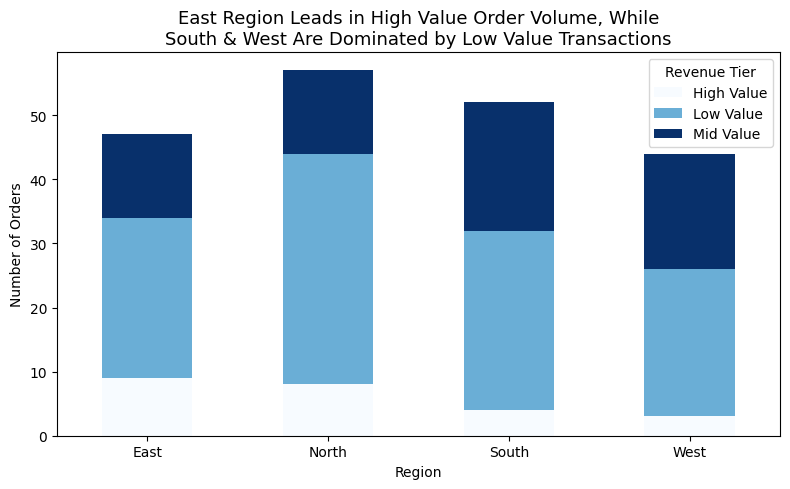

rev_tier  High Value  Low Value  Mid Value
region                                    
East               9         25         13
North              8         36         13
South              4         28         20
West               3         23         18


In [84]:
# E1 — Stacked Bar: Revenue Tier by Region (10 pts)
# Step 1: crosstab = pd.crosstab(df['region'], df['rev_tier'])
# Step 2: .plot(kind='bar', stacked=True, figsize=(...), colormap='Blues')
# Step 3: Insight title, xlabel, ylabel, legend
# Step 4: savefig BEFORE show
ct = pd.crosstab(ak['region'], ak['rev_tier'])
ax = ct.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Blues')
ax.set_title('East Region Leads in High Value Order Volume, While\nSouth & West Are Dominated by Low Value Transactions', fontsize=13)
ax.set_xlabel('Region')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.legend(title='Revenue Tier')
plt.tight_layout()
plt.savefig('revenue_tier_by_region.png', dpi=150)
plt.show()
print(ct)


<!-- E1 NRA INSIGHT — WRITE HERE -->

**N:** East leads with 9 High Value orders, North has 8, South 4, and West 3.

**R:** The East region not only has the most High Value orders but also the smallest proportion of Low Value orders, suggesting a more affluent customer base or a stronger presence of high-value customers compared to other regions.

**A:** The client should replicate East’s successful practices (e.g., premium product targeting, VIP engagement programs) in South and West to shift more orders from Low to High Value tier.


---

### ⭐ Bonus Task — Apply Pipeline: Custom Scoring Engine (10★ pts)

The client wants a single `'order_score'` column that combines revenue tier, discount severity,
and segment into a numeric priority score using their internal rules:

**Score formula (implement as a named function applied row-wise):**
```
base_score = rev_score (from C1)
tier_bonus:   High Value → +3,  Mid Value → +1,  Low Value → 0
disc_penalty: Heavy → -2,  Moderate → -1,  No Discount → 0
seg_bonus:    VIP → +2,  Premium → +1,  Regular → 0
final = base_score + tier_bonus + disc_penalty + seg_bonus
```

Steps:
1. Ensure `rev_score`, `rev_tier`, `discount_label`, `segment` are all on `df`
2. Write `order_score(row)` applying the formula above
3. Apply row-wise → `df['order_score']`
4. Print: top 10 orders by `order_score` (order_id, rev_tier, discount_label, segment, order_score)
5. Print `.describe()` of `order_score`
6. One NRA insight: what does the score distribution reveal about order quality?


In [70]:
# ⭐ BONUS — Order Scoring Engine (10★ pts)
# All required columns should already exist from Tasks A, B, C
# Step 1: Define order_score(row) with the formula above
# Step 2: df.apply(order_score, axis=1) → df['order_score']
# Step 3: Print top 10 by order_score
# Step 4: Print describe()
# Step 5: NRA insight in markdown cell below
tier_bonus = {'High Value':3, 'Mid Value':1, 'Low Value':0}
disc_penalty= {'Heavy':-2, 'Moderate':-1, 'No Discount':0}
seg_bonus   = {'VIP':2, 'Premium':1, 'Regular':0}

def order_score(row):
    return round(
        row['rev_score']
        + tier_bonus.get(row['rev_tier'], 0)
        + disc_penalty.get(row['discount_label'], 0)
        + seg_bonus.get(row['segment'], 0),
        4
    )

ak['order_score'] = ak.apply(order_score, axis=1)
print("=== BONUS top 10 ===")
top10 = ak.nlargest(10, 'order_score')[['order_id','rev_tier','discount_label','segment','order_score']]
print(top10.to_string(index=False))
print()
print("=== order_score describe ===")
print(ak['order_score'].describe().round(4))




=== BONUS top 10 ===
order_id   rev_tier discount_label segment  order_score
 ORD1066 High Value    No Discount Premium      59.1000
 ORD1055 High Value    No Discount Regular      58.1000
 ORD1186 High Value    No Discount Regular      53.4000
 ORD1113 High Value       Moderate Premium      52.7278
 ORD1145  Mid Value    No Discount Regular      51.4000
 ORD1185  Low Value       Moderate     VIP      50.7278
 ORD1094  Low Value    No Discount Regular      50.4000
 ORD1120  Low Value       Moderate Premium      49.7278
 ORD1173 High Value       Moderate     VIP      49.4860
 ORD1170 High Value    No Discount Regular      48.9000

=== order_score describe ===
count    200.0000
mean      20.0511
std       15.3808
min       -1.2960
25%        6.6000
50%       17.1180
75%       31.1500
max       59.1000
Name: order_score, dtype: float64


<!-- BONUS NRA INSIGHT — WRITE HERE -->

**N: The mean score is 20.05, with a standard deviation of 15.38; the minimum is -1.30 and the maximum is 59.10.**

**R: A wide standard deviation indicates highly variable order quality — while a few orders score >50, the negative minimum reveals some orders are so heavily discounted and low‑value that they actually degrade the ideal customer profile.**

**A: The client should set a minimum order_score threshold (e.g., 10) for marketing promotions, and consider why orders scored below zero are being accepted — possibly adjusting discount policies or minimum order values.**


---
## 📊 Section 4 — Scoring Rubric

| Task | Sub-Task | Pts | What Is Checked |
|------|----------|-----|-----------------|
| **A** | A1 Revenue Tier | 8 | Named function, correct 3 tiers, apply(), value_counts + 8 rows |
| | A2 Discount Label | 7 | Named function, 3 labels, apply(), value_counts + 5 rows |
| | A3 Insight | 5 | NRA format; exact High Value % cited; specific action |
| **B** | B1 Rev Per Unit | 5 | Lambda + axis=1 (or vectorized), round(2), correct output |
| | B2 ID Reformatter | 8 | Lambda strips ORD, prepends SHOPEASE-, output correct |
| | B3 Priority Flag | 7 | Lambda axis=1, 3 tiers in correct order, value_counts + 5 rows |
| **C** | C1 Rev Score | 10 | Named function, formula correct, axis=1, describe + 6 rows |
| | C2 Price Flag | 10 | groupby transform first, named function, crosstab + 5 rows |
| **D** | D1 Segment Recode | 5 | .map() with dict, correct 3 labels, value_counts + 4 rows |
| | D2 Action Code | 5 | .map() with dict, correct 3 codes + NRA insight with counts |
| **E** | E1 Stacked Bar | 10 | Crosstab → stacked bar, insight title, savefig before show, NRA below |
| **★ Bonus** | Scoring Engine | 10 | All 4 components in formula, correct apply, top-10 table, NRA |
| **TOTAL** | | **80 + 10★** | |

---

### Key Takeaway
`.apply()` is not a shortcut — it's a last resort that enables *any* custom logic.
The professional habit is: vectorize first (arithmetic, string methods, `.map()` for recoding),
reach for `apply()` only when no vectorized alternative exists.
Every analyst who says "I couldn't do it, Pandas doesn't have that function" hasn't learned apply() yet.

---

### Interview Frame
> "In Pandas, I use `.apply()` for custom business rules that can't be vectorized —
> revenue tiers, multi-column flags, string reformatting. For everything else I use
> vectorized operations or `.map()` which are 10–100× faster.
> The key decision is: can I express this as math or a dictionary lookup? If yes,
> don't touch apply(). If no, apply() is the right tool."

---
